# col-anchored three-panel methylation heatmap

Replaces the independent **col / rdd / met** residual panels in `260514_dmw_methylation_matrices_by_genotype.ipynb` with a **differential** three-panel layout:

| Panel | Quantity | Meaning |
|---|---|---|
| 1 | `col_res` | col-0 within-genotype cluster residual (`obs_p − p0`) — baseline |
| 2 | `rdd_res − col_res` | how rdd's cluster-specific residual differs from col's, per DMW × cluster |
| 3 | `met_res − col_res` | same for met (T-MET) |

Hypothesis: panel 2 should appear as the visual **reverse** of panel 1 because the rdd triple mutant fails to demethylate, so clusters where col-0 is naturally demethylated (negative residual) become positive in `rdd − col`.

Two plotting cases are produced from the same matrices:

1. **Raw differential values** — panels share one symmetric coolwarm scale
2. **Row z-score** — each panel z-scored across the 17 clusters and clipped to ±2.5, matching the visualization convention used by the rest of the project

**Row order is anchored to col-0** (Ward / Euclidean linkage on the col z-scored residual). The same order is reused for the two differential panels so all three panels align row-for-row.

**Pre-filter:** DMWs overlapping the chr2 pericentromere region **3.23–3.51 Mb** are excluded from the curated row set before any computation.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.stats import zscore
from scipy.special import logit, expit
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from ALLCools.mcds import MCDS

In [2]:
# ---- EDIT PATHS HERE ----
MCDS_PATHS = [
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_0.mcds",
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_1.mcds",
]
CHUNKS_GFF = "/ceph/MethDev/pbio/andy/JW/section_4/chunks_CG_minfilt.gff"
META_PATH  = "/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv"

OUTDIR     = "/ceph/MethDev/pbio/kay/data/three_panel_col_anchored"
FIG_OUTDIR = "/ceph/MethDev/pbio/kay/figures/heatmaps"
os.makedirs(OUTDIR,     exist_ok=True)
os.makedirs(FIG_OUTDIR, exist_ok=True)

MC_TYPE      = "CGN"
MIN_COV      = 50
HIGH_METH_TH = 0.10

# DMWs overlapping this region are dropped before any aggregation
EXCLUDE_CHR    = "2"
EXCLUDE_START  = 3_230_000
EXCLUDE_END    = 3_510_000

GENOTYPE_MAP = {"1": "col", "2": "rdd", "3": "met"}
GENOTYPES    = ["col", "rdd", "met"]

cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem',
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase',
}
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
    '16 Myrosinase', '12 S phase', '15 G2M phase',
]

In [3]:
# Load MCDS + curated CG chunks + cell metadata
mcds = MCDS.open(mcds_paths=MCDS_PATHS, var_dim="dmw")
meta = pd.read_csv(META_PATH).set_index("cell_id")
print(f"MCDS dims: {dict(mcds.dims)}")

chunks = pd.read_csv(
    CHUNKS_GFF, sep="\t", header=None, comment="#",
    usecols=[0, 3, 4], names=["chrom", "start", "end"],
)
chunks["chrom"] = chunks["chrom"].astype(str).str.replace("^chr", "", regex=True)
chunks["start"] = chunks["start"].astype(int) + 1   # GFF is 0-based BED-style here
chunks["end"]   = chunks["end"].astype(int)
n_before = len(chunks)

# Drop pericentromeric chr2 region (overlap with [EXCLUDE_START, EXCLUDE_END))
mask_excl = (
    (chunks["chrom"] == EXCLUDE_CHR)
    & (chunks["start"] < EXCLUDE_END)
    & (chunks["end"]   > EXCLUDE_START)
)
chunks = chunks[~mask_excl].reset_index(drop=True)
print(f"Excluded chr{EXCLUDE_CHR}:{EXCLUDE_START:,}–{EXCLUDE_END:,} DMWs: "
      f"{int(mask_excl.sum())} / {n_before}  →  {len(chunks)} curated DMWs remain")

mcds_bed = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values.astype(str),
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})
keep = mcds_bed.merge(chunks, on=["chrom", "start", "end"], how="inner")
print(f"Curated chunks matched in MCDS: {len(keep)} / {len(chunks)}")
mcds = mcds.sel(dmw=keep["dmw_id"].tolist())
print(f"Filtered MCDS dims: {dict(mcds.dims)}")

genotype_per_cell = (
    pd.Series(mcds["cell"].values, index=mcds["cell"].values)
    .str.split("_").str[2]
    .map(GENOTYPE_MAP)
)
print("\nGenotype counts (all MCDS cells):")
print(genotype_per_cell.value_counts())

MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 22467, 'mc_type': 4}
Excluded chr2:3,230,000–3,510,000 DMWs: 105 / 3124  →  3019 curated DMWs remain
Curated chunks matched in MCDS: 3019 / 3019
Filtered MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 3019, 'mc_type': 4}

Genotype counts (all MCDS cells):
col    3059
met    1532
rdd    1480
Name: count, dtype: int64


In [4]:
# Per-cluster mc/cov aggregation, factored so we can call per genotype
mc_cell  = mcds.sel(mc_type=MC_TYPE, count_type="mc" ).dmw_da.to_pandas()
cov_cell = mcds.sel(mc_type=MC_TYPE, count_type="cov").dmw_da.to_pandas()

shared_cells = mc_cell.index.intersection(meta.index).intersection(genotype_per_cell.dropna().index)
mc_cell      = mc_cell.loc[shared_cells]
cov_cell     = cov_cell.loc[shared_cells]
cluster_of   = meta.loc[shared_cells, "merged_cluster"]
genotype_of  = genotype_per_cell.loc[shared_cells]

print(f"Cells with cluster + genotype labels: {len(shared_cells)}")
print(genotype_of.value_counts())

def per_cluster_sums(genotype):
    cells = shared_cells[genotype_of == genotype]
    mc_g  = mc_cell.loc[cells].copy()
    cov_g = cov_cell.loc[cells].copy()
    mc_g ["cluster"] = cluster_of.loc[cells]
    cov_g["cluster"] = cluster_of.loc[cells]
    c = mc_g .groupby("cluster").sum().T
    m = cov_g.groupby("cluster").sum().T
    return c, m

def compute_matrices(cluster_c, cluster_m):
    """Fit per-cluster logit offsets and return (obs_p, residual) for one genotype."""
    global_c = cluster_c.sum(axis=0)
    global_m = cluster_m.sum(axis=0)
    global_p = global_c / global_m
    d        = logit(np.clip(global_p, 1e-6, 1 - 1e-6))
    deltas   = d - np.average(d, weights=global_m)

    dmw_m = cluster_m.sum(axis=1)
    valid = dmw_m >= MIN_COV
    cluster_c = cluster_c[valid]
    cluster_m = cluster_m[valid]
    dmw_c = cluster_c.sum(axis=1)
    dmw_m = dmw_m[valid]

    pbar = np.clip(dmw_c / dmw_m, 1e-6, 1 - 1e-6)
    expected = logit(pbar).values[:, None] + deltas.values[None, :]
    p0 = pd.DataFrame(expit(expected), index=cluster_c.index, columns=cluster_c.columns)

    obs_p    = (cluster_c / cluster_m.replace(0, np.nan)).fillna(0)
    residual = obs_p - p0
    return obs_p, residual

Cells with cluster + genotype labels: 5908
col    2938
met    1521
rdd    1449
Name: count, dtype: int64


In [5]:
# Compute per-genotype residuals, then anchor all to the col-0 row set
raw_by_geno = {}
res_by_geno = {}
for g in GENOTYPES:
    c, m = per_cluster_sums(g)
    obs_p, residual = compute_matrices(c, m)
    raw_by_geno[g] = obs_p
    res_by_geno[g] = residual
    print(f"{g}: DMWs passing per-genotype coverage filter (sum cov >= {MIN_COV}): {obs_p.shape[0]}")

canonical_rows = raw_by_geno["col"][
    (raw_by_geno["col"] >= HIGH_METH_TH).any(axis=1)
].index
print(f"\ncol-0 canonical row set (raw >= {HIGH_METH_TH} in any cluster): {len(canonical_rows)} DMWs")

for g in GENOTYPES:
    raw_by_geno[g] = raw_by_geno[g].reindex(canonical_rows)
    res_by_geno[g] = res_by_geno[g].reindex(canonical_rows)
    n_missing = res_by_geno[g].isna().any(axis=1).sum()
    print(f"{g}: rows after anchoring = {res_by_geno[g].shape[0]}  (NaN rows from low coverage: {n_missing})")

col: DMWs passing per-genotype coverage filter (sum cov >= 50): 3019
rdd: DMWs passing per-genotype coverage filter (sum cov >= 50): 3011
met: DMWs passing per-genotype coverage filter (sum cov >= 50): 3019

col-0 canonical row set (raw >= 0.1 in any cluster): 2983 DMWs
col: rows after anchoring = 2983  (NaN rows from low coverage: 0)
rdd: rows after anchoring = 2983  (NaN rows from low coverage: 8)
met: rows after anchoring = 2983  (NaN rows from low coverage: 0)


In [6]:
# Relabel clusters and build the three differential panels
def relabel(df):
    df = df.rename(columns=cluster_mapping)
    return df[[c for c in cluster_order if c in df.columns]]

res_lab = {g: relabel(res_by_geno[g]) for g in GENOTYPES}

# Three panels of the col-anchored figure
panels = {
    "col":         res_lab["col"],
    "rdd − col":   res_lab["rdd"] - res_lab["col"],
    "met − col":   res_lab["met"] - res_lab["col"],
}

for name, df in panels.items():
    finite = df.to_numpy()[np.isfinite(df.to_numpy())]
    print(f"{name:>10s}: shape {df.shape}  range [{finite.min():+.3f}, {finite.max():+.3f}]")

# Save TSVs (un-z-scored) for downstream use
panels["col"].to_csv       (f"{OUTDIR}/col_residual.tsv",         sep="\t")
panels["rdd − col"].to_csv (f"{OUTDIR}/rdd_minus_col_residual.tsv", sep="\t")
panels["met − col"].to_csv (f"{OUTDIR}/met_minus_col_residual.tsv", sep="\t")
print(f"\nSaved 3 TSVs to {OUTDIR}/")

       col: shape (2983, 17)  range [-0.948, +0.796]
 rdd − col: shape (2983, 17)  range [-1.469, +1.055]
 met − col: shape (2983, 17)  range [-1.237, +1.123]

Saved 3 TSVs to /ceph/MethDev/pbio/kay/data/three_panel_col_anchored/


In [7]:
# Anchor the row order on the col panel.
# Use the same Ward / Euclidean linkage on col-0 row z-scores that the rest of
# the project uses for clustermaps, then reuse the leaf order for all 3 panels.
col_complete = panels["col"].dropna()
col_z = col_complete.apply(zscore, axis=1).clip(lower=-2.5, upper=2.5)
linkage_mat = linkage(pdist(col_z.values, metric="euclidean"), method="ward")
row_order = col_z.index[leaves_list(linkage_mat)]
print(f"Row order set by col-0 Ward dendrogram on {len(row_order)} DMWs "
      f"(dropped {len(panels['col']) - len(row_order)} rows that had NaN in col)")

Row order set by col-0 Ward dendrogram on 2983 DMWs (dropped 0 rows that had NaN in col)


In [8]:
# Shared three-panel plotter
def plot_three_panels(panels, row_order, mode, suptitle, save_name=None):
    """mode = 'raw'  → shared symmetric color scale across panels
       mode = 'zscore' → row z-score per panel, clipped to ±2.5 (shared scale)."""
    assert mode in ("raw", "zscore")

    mats = {}
    for name, df in panels.items():
        sub = df.reindex(row_order)
        if mode == "zscore":
            sub = sub.apply(zscore, axis=1).clip(lower=-2.5, upper=2.5)
        mats[name] = sub

    if mode == "raw":
        vmax = max(np.nanmax(np.abs(m.to_numpy())) for m in mats.values())
        vmin, vmax = -vmax, vmax
        cbar_label = "Residual (col)  or  Δ residual (rdd−col, met−col)"
    else:
        vmin, vmax = -2.5, 2.5
        cbar_label = "Row z-score (clipped ±2.5)"

    fig, axes = plt.subplots(
        1, 3, figsize=(22, 14), sharey=True,
        gridspec_kw={"wspace": 0.05},
    )
    panel_names = list(panels.keys())
    for ax, name in zip(axes, panel_names):
        sns.heatmap(
            mats[name], ax=ax,
            cmap="coolwarm", center=0, vmin=vmin, vmax=vmax,
            cbar=False, yticklabels=False,
        )
        ax.set_title(name, fontsize=13)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.set_xlabel("")

        cols = list(mats[name].columns)
        mesophyll_end = sum(1 for c in cols if c.endswith(" M"))
        epidermis_end = mesophyll_end + sum(1 for c in cols if c.endswith(" E"))
        for pos in (mesophyll_end, epidermis_end):
            ax.axvline(pos, color="black", lw=1.2, linestyle="--")
        for i, col_name in enumerate(cols):
            if "Senescent M" in col_name or "Senescent E" in col_name:
                ax.axvline(i + 1, color="black", lw=0.8, linestyle=":")

    axes[0].set_ylabel(f"DMWs (n={len(row_order)}, col-anchored order)", fontsize=12)

    # One shared colorbar to the right of the figure
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="coolwarm")
    sm.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.7])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(cbar_label, fontsize=11)

    fig.suptitle(suptitle, fontsize=14, y=0.995)
    if save_name is not None:
        out_path = f"{FIG_OUTDIR}/{save_name}"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved heatmap: {out_path}")
    plt.show()

## Case 1 — raw differential values

All three panels use one shared symmetric coolwarm scale. Useful when you want to compare absolute magnitudes: e.g. is `rdd − col` of comparable amplitude to col's own residual, or are mutant shifts much larger than within-genotype cluster structure?

Saved heatmap: /ceph/MethDev/pbio/kay/figures/heatmaps/col_anchored_three_panel_raw.png


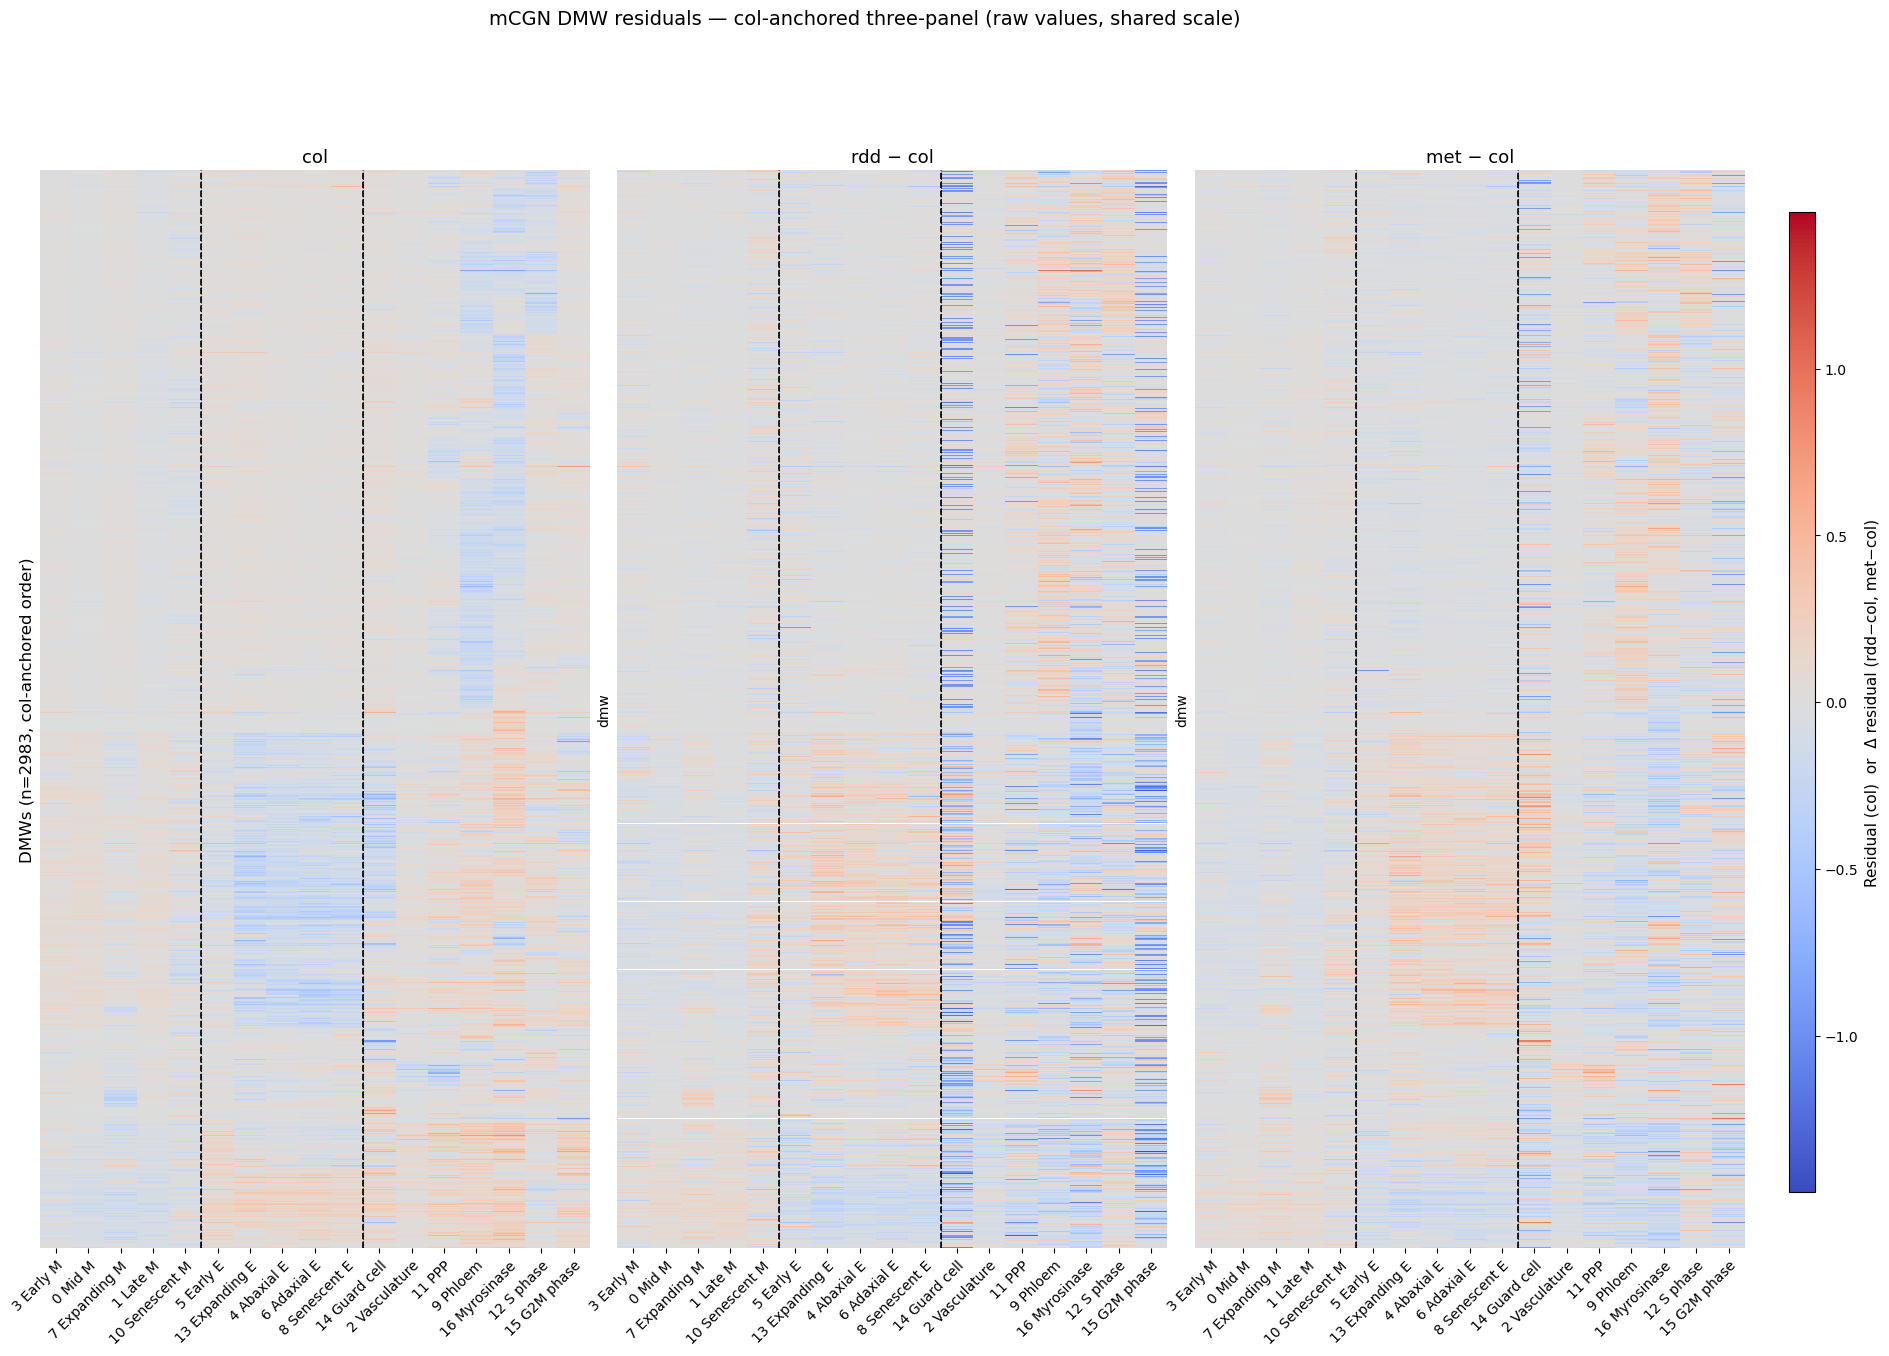

In [9]:
plot_three_panels(
    panels,
    row_order,
    mode="raw",
    suptitle=f"m{MC_TYPE} DMW residuals — col-anchored three-panel (raw values, shared scale)",
    save_name="col_anchored_three_panel_raw.png",
)

## Case 2 — row z-score per panel

Each panel is independently row-z-scored (then clipped to ±2.5). This maximizes within-row contrast and matches the visualization convention used elsewhere in the project. Magnitudes are no longer comparable between panels, but cluster-specific patterns become easier to read — useful for confirming the "reverse plot" hypothesis: where col is blue, `rdd − col` should be red, and vice versa.

Saved heatmap: /ceph/MethDev/pbio/kay/figures/heatmaps/col_anchored_three_panel_zscore.png


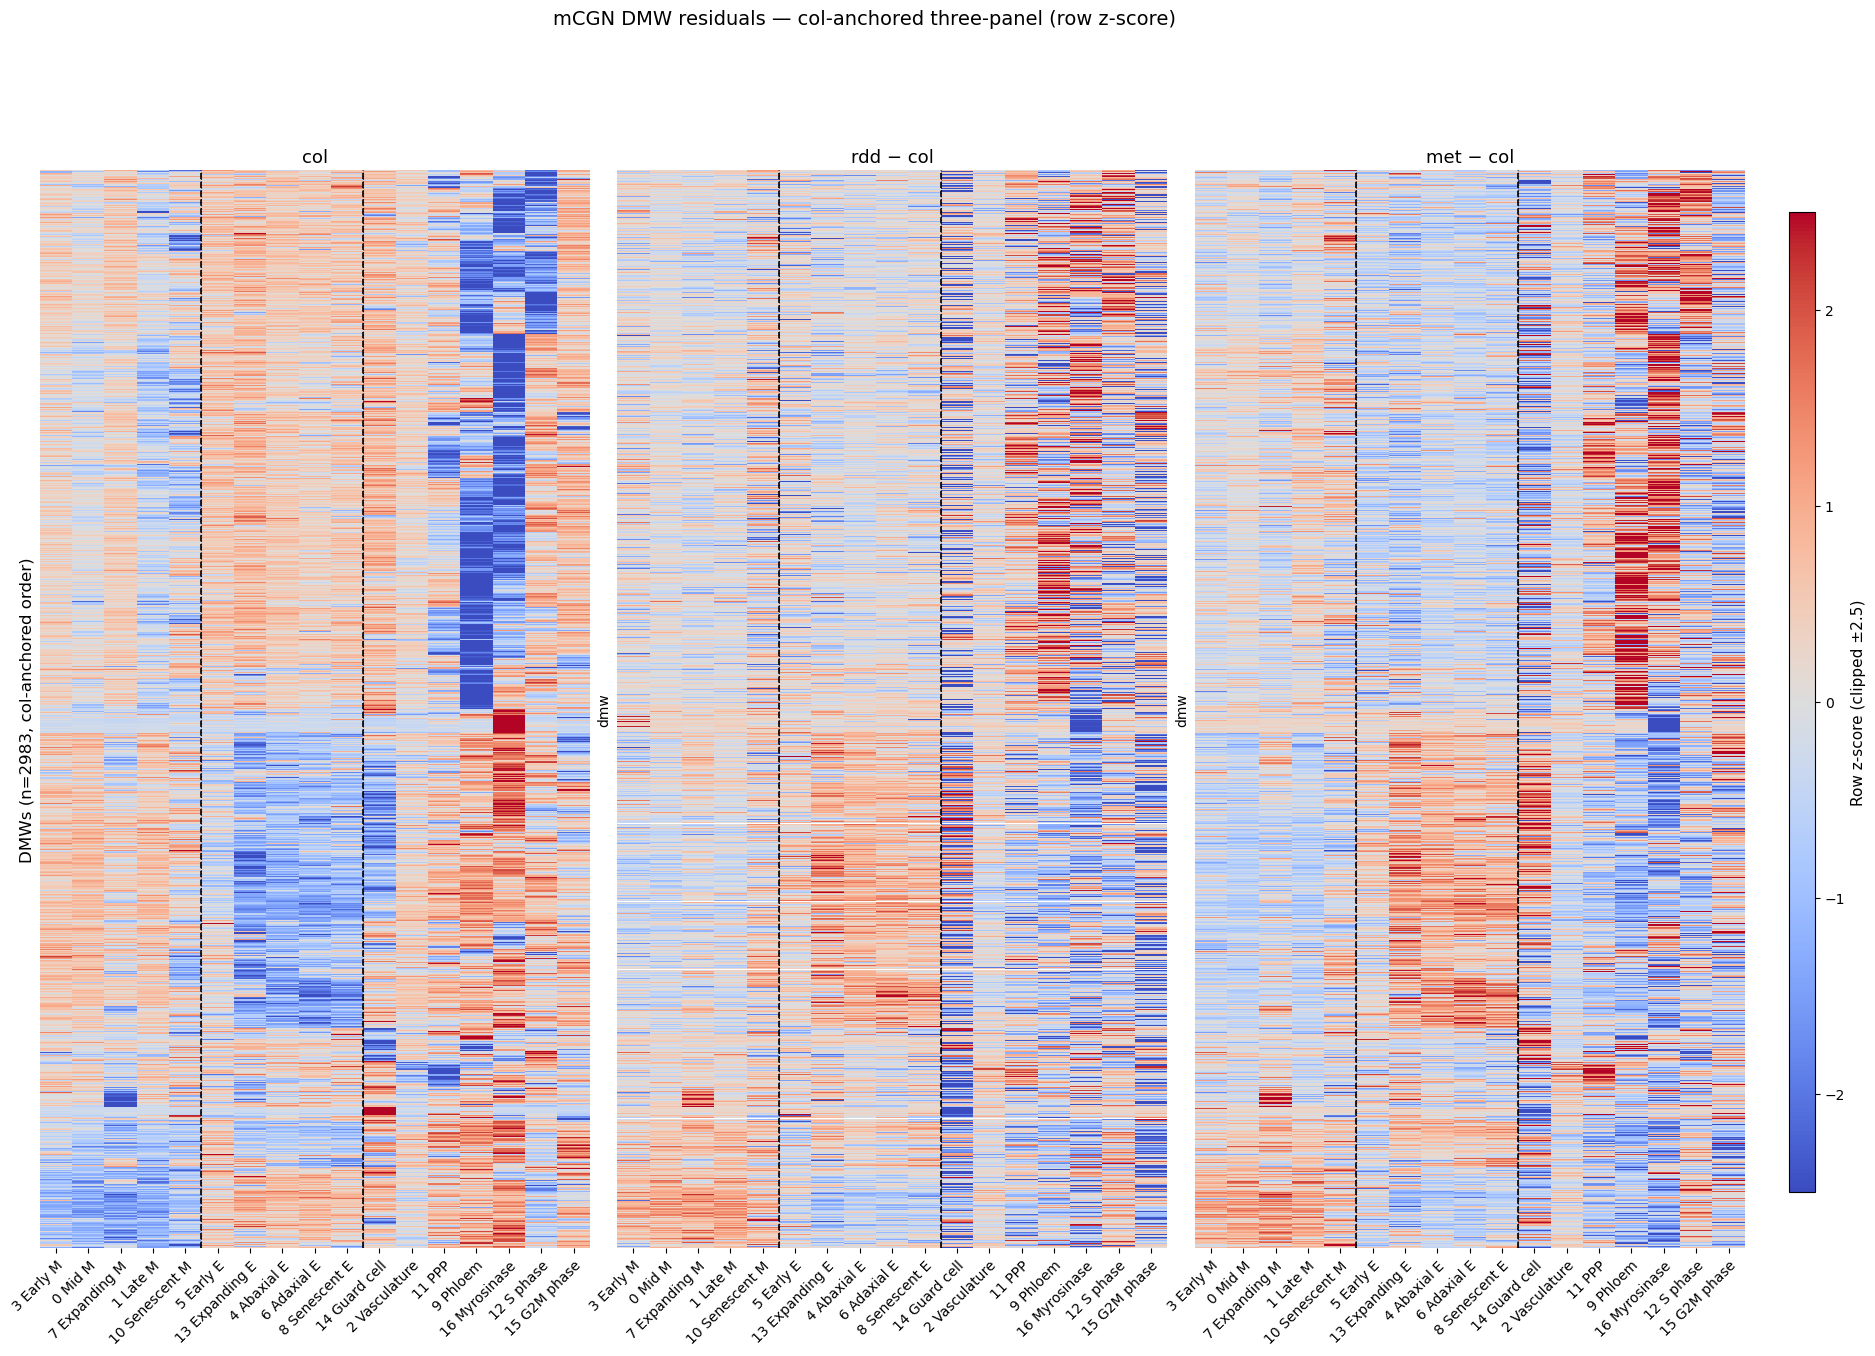

In [10]:
plot_three_panels(
    panels,
    row_order,
    mode="zscore",
    suptitle=f"m{MC_TYPE} DMW residuals — col-anchored three-panel (row z-score)",
    save_name="col_anchored_three_panel_zscore.png",
)

## Reverse-correlation diagnostic

Per-DMW Pearson correlation between the **col** row and the **rdd − col** row (across the 17 clusters). A strongly negative distribution would support the visual "reverse plot" interpretation.

n DMWs: 2975
median ρ(col, rdd−col):       -0.537
fraction with ρ < 0:           92.10%
fraction with ρ < −0.5:        53.88%


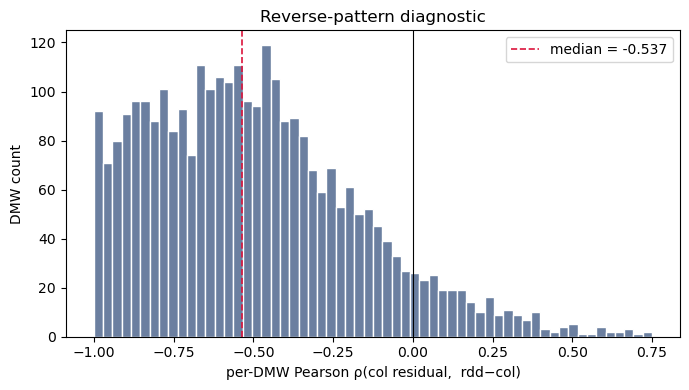

In [11]:
common_idx = panels["col"].dropna().index.intersection(panels["rdd − col"].dropna().index)
A = panels["col"].loc[common_idx].to_numpy()
B = panels["rdd − col"].loc[common_idx].to_numpy()
A = A - A.mean(axis=1, keepdims=True)
B = B - B.mean(axis=1, keepdims=True)
num = (A * B).sum(axis=1)
den = np.sqrt((A * A).sum(axis=1) * (B * B).sum(axis=1))
rho = pd.Series(np.where(den > 0, num / den, np.nan), index=common_idx)
rho = rho.dropna()

print(f"n DMWs: {len(rho)}")
print(f"median ρ(col, rdd−col):       {rho.median():+.3f}")
print(f"fraction with ρ < 0:           {(rho < 0).mean():.2%}")
print(f"fraction with ρ < −0.5:        {(rho < -0.5).mean():.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rho.values, bins=60, color="#6b7fa0", edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(rho.median(), color="crimson", lw=1.2, linestyle="--",
           label=f"median = {rho.median():+.3f}")
ax.set_xlabel("per-DMW Pearson ρ(col residual,  rdd−col)")
ax.set_ylabel("DMW count")
ax.set_title("Reverse-pattern diagnostic")
ax.legend()
plt.tight_layout()
plt.show()

## §7-style col-anchored bulk-shift — Figure 3 inset (chr2 pericentromere excluded)

Reproduction of §7 from `260611_master_pipeline.ipynb`: replace each genotype's null with col-0's `p0`. Now rdd panels shift red (hypermethylated vs col) and met panels shift blue (hypomethylated vs col), while cluster-specific structure remains visible on top.

Plotted un-z-scored on a shared ±0.7 diverging scale, using the col-0 row order from cell 7 (Ward / Euclidean on col z-scored residuals) so panels line up row-for-row with Fig 3. Only difference from the master notebook's §7: chr2 pericentromere DMWs (3.23–3.51 Mb, 105 DMWs) are excluded.

Saved heatmap: /ceph/MethDev/pbio/kay/figures/heatmaps/fig3b_col_rdd_met_anchored_chr2excl.svg


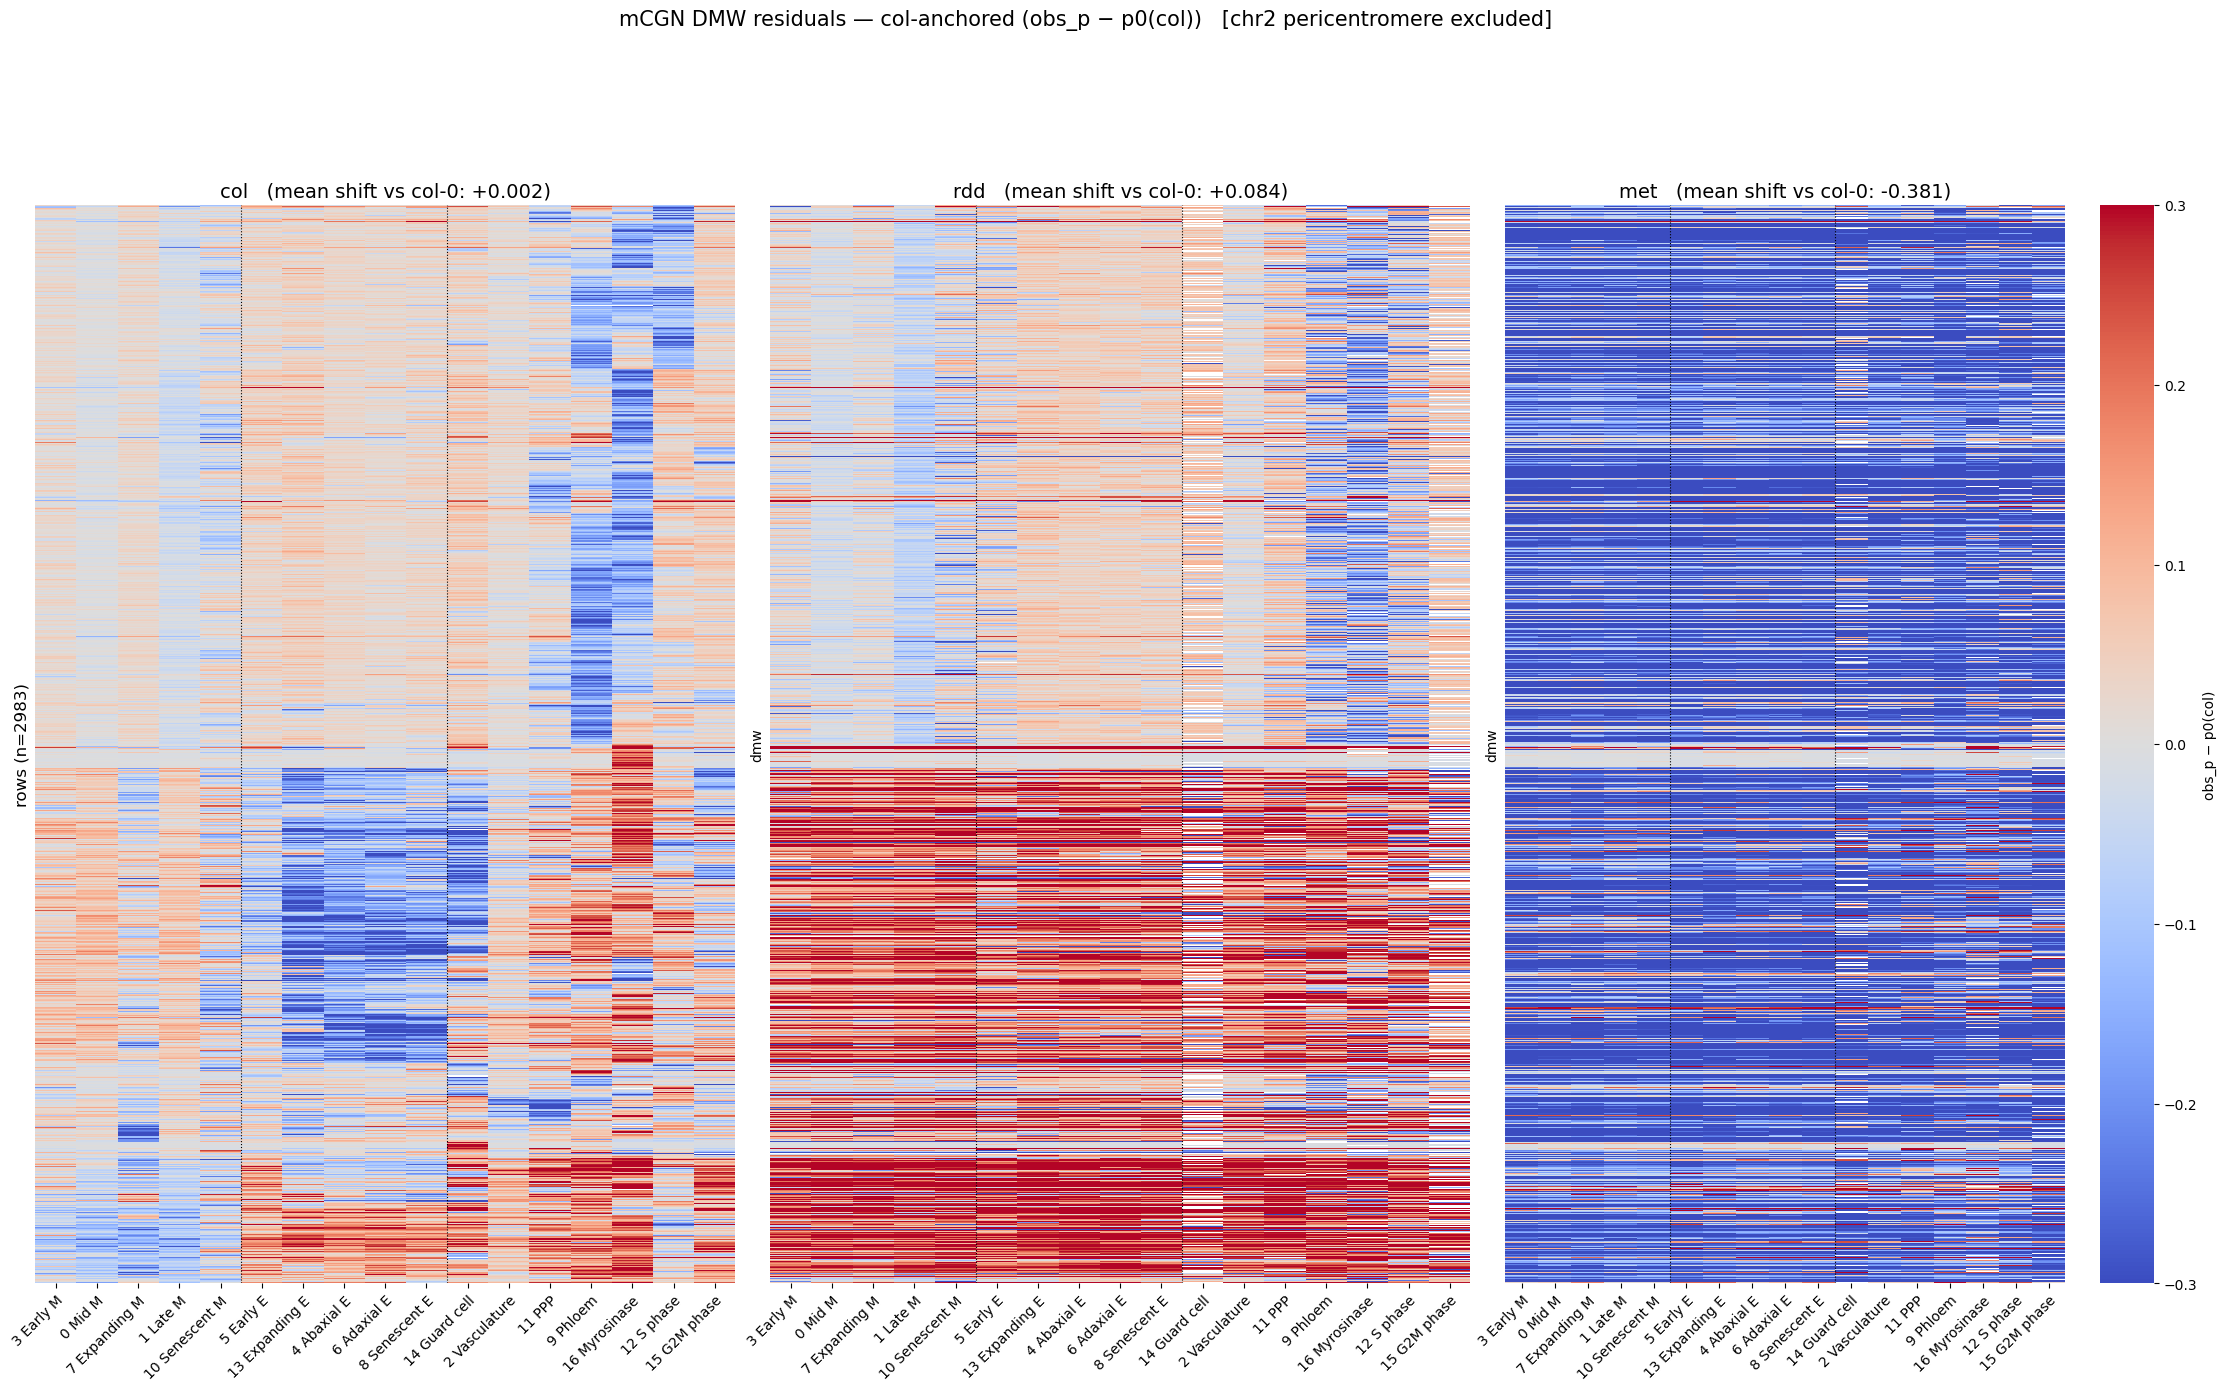

In [12]:
# Reproduce the 0611 master notebook's §7 plot: obs_p[geno] - p0(col),
# un-z-scored, shared ±0.7 diverging scale, col-0 Ward row order from cell 7.
# Same logic as dmw_utils.compute_col_anchored_residuals + plot_genotype_panels.

# 1) Fit col-0 null (deltas + per-DMW pbar) once, using ONLY col cells
col_c, col_m = per_cluster_sums("col")
g_p          = col_c.sum(axis=0) / col_m.sum(axis=0)
d            = logit(np.clip(g_p, 1e-6, 1 - 1e-6))
deltas_col   = d - np.average(d, weights=col_m.sum(axis=0))
pbar_col     = np.clip(col_c.sum(axis=1) / col_m.sum(axis=1), 1e-6, 1 - 1e-6)
col_p0 = pd.DataFrame(
    expit(logit(pbar_col).values[:, None] + deltas_col.values[None, :]),
    index=col_c.index, columns=col_c.columns,
)

# 2) For each genotype: obs_p - col_p0, with NaN where per-DMW coverage < MIN_COV,
#    then restrict rows to the col-0 canonical high-methylation set.
anchored = {}
for g in GENOTYPES:
    c, m  = per_cluster_sums(g)
    obs_p = c / m.replace(0, np.nan)
    obs_p = obs_p.where(m.sum(axis=1) >= MIN_COV, np.nan)
    obs_p = obs_p.reindex(col_p0.index)
    anchored[g] = (obs_p - col_p0).reindex(canonical_rows)

anchored_lab = {g: relabel(anchored[g]) for g in GENOTYPES}

# 3) Plot three side-by-side panels — un-z-scored, shared ±0.7 coolwarm scale,
#    rows in col-0 Ward order so panels align row-for-row with Fig 3.
VMAX = 0.3
fig, axes = plt.subplots(
    1, 3, figsize=(28, 14), sharey=True,
    gridspec_kw={"wspace": 0.05},
)
for ax, g in zip(axes, GENOTYPES):
    mat = anchored_lab[g].reindex(row_order)
    sns.heatmap(
        mat, ax=ax,
        cmap="coolwarm", center=0, vmin=-VMAX, vmax=VMAX,
        cbar=(g == GENOTYPES[-1]),
        cbar_kws={"label": "obs_p − p0(col)"},
        yticklabels=False,
    )
    mean_shift = float(np.nanmean(mat.values))
    ax.set_title(f"{g}   (mean shift vs col-0: {mean_shift:+.3f})", fontsize=14)
    ax.set_xlabel("")
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45, ha="right", rotation_mode="anchor",
    )
    for i, col_name in enumerate(mat.columns):
        if "Senescent M" in col_name or "Senescent E" in col_name:
            ax.axvline(i + 1, color="black", lw=0.8, linestyle=":")

axes[0].set_ylabel(f"rows (n={len(row_order)})", fontsize=12)
fig.suptitle(
    f"m{MC_TYPE} DMW residuals — col-anchored (obs_p − p0(col))   "
    f"[chr2 pericentromere excluded]",
    fontsize=15, y=1.02,
)

out_path = f"{FIG_OUTDIR}/fig3b_col_rdd_met_anchored_chr2excl.svg"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved heatmap: {out_path}")
plt.show()

## §7 + row-centered subtraction — visual anticorrelation between col and (mutant − col)

The whole point of building the col-anchored framework above is to **subtract col from each mutant** and see whether the resulting pattern is the **visual reverse** of col's own residual pattern.

Within the col-anchored framework (everything against `p0(col)`):

| Panel | Formula | Simplifies to |
|---|---|---|
| col | `obs_p[col] − p0(col)` | col-0 residual against its own null |
| rdd − col | `(obs_p[rdd] − p0(col)) − (obs_p[col] − p0(col))` | `obs_p[rdd] − obs_p[col]` |
| met − col | `(obs_p[met] − p0(col)) − (obs_p[col] − p0(col))` | `obs_p[met] − obs_p[col]` |

**Bulk-shift problem.** Without further normalization, `obs_p[rdd] − obs_p[col]` decomposes into:

```
(rdd − col)_{DMW, cluster} = bulk_shift_{DMW}  +  cluster_specific_anticorrelation
```

The bulk hypermethylation of rdd (and hypomethylation of met) per DMW dominates — the panel washes uniformly red or blue and the cluster-specific signal we want is buried.

**Fix: row-center each panel.** Subtract the per-DMW mean (across the 17 clusters) from every panel:

```
panel_centered[i, :] = panel[i, :] − mean(panel[i, :])
```

This removes the per-DMW bulk shift while preserving the cluster-specific pattern AND keeping real magnitudes (unlike z-scoring). Now red/blue intensity in `(mutant − col)` reflects "deviation from this DMW's mutant-vs-col average," which is exactly the anticorrelation signal.

Plotted on a shared symmetric coolwarm scale, same col-0 Ward row order as Fig 3.

Per-panel data range — before vs after row-centering:
         col:  raw [-0.874, +0.796]   →  centered [-0.837, +0.685]
   rdd − col:  raw [-1.000, +1.000]   →  centered [-1.188, +0.959]
   met − col:  raw [-1.000, +1.000]   →  centered [-1.037, +1.079]

Shared color scale (centered): ±1.19

Saved heatmap: /ceph/MethDev/pbio/kay/figures/heatmaps/col_anchored_subtraction_rowcentered_chr2excl.svg


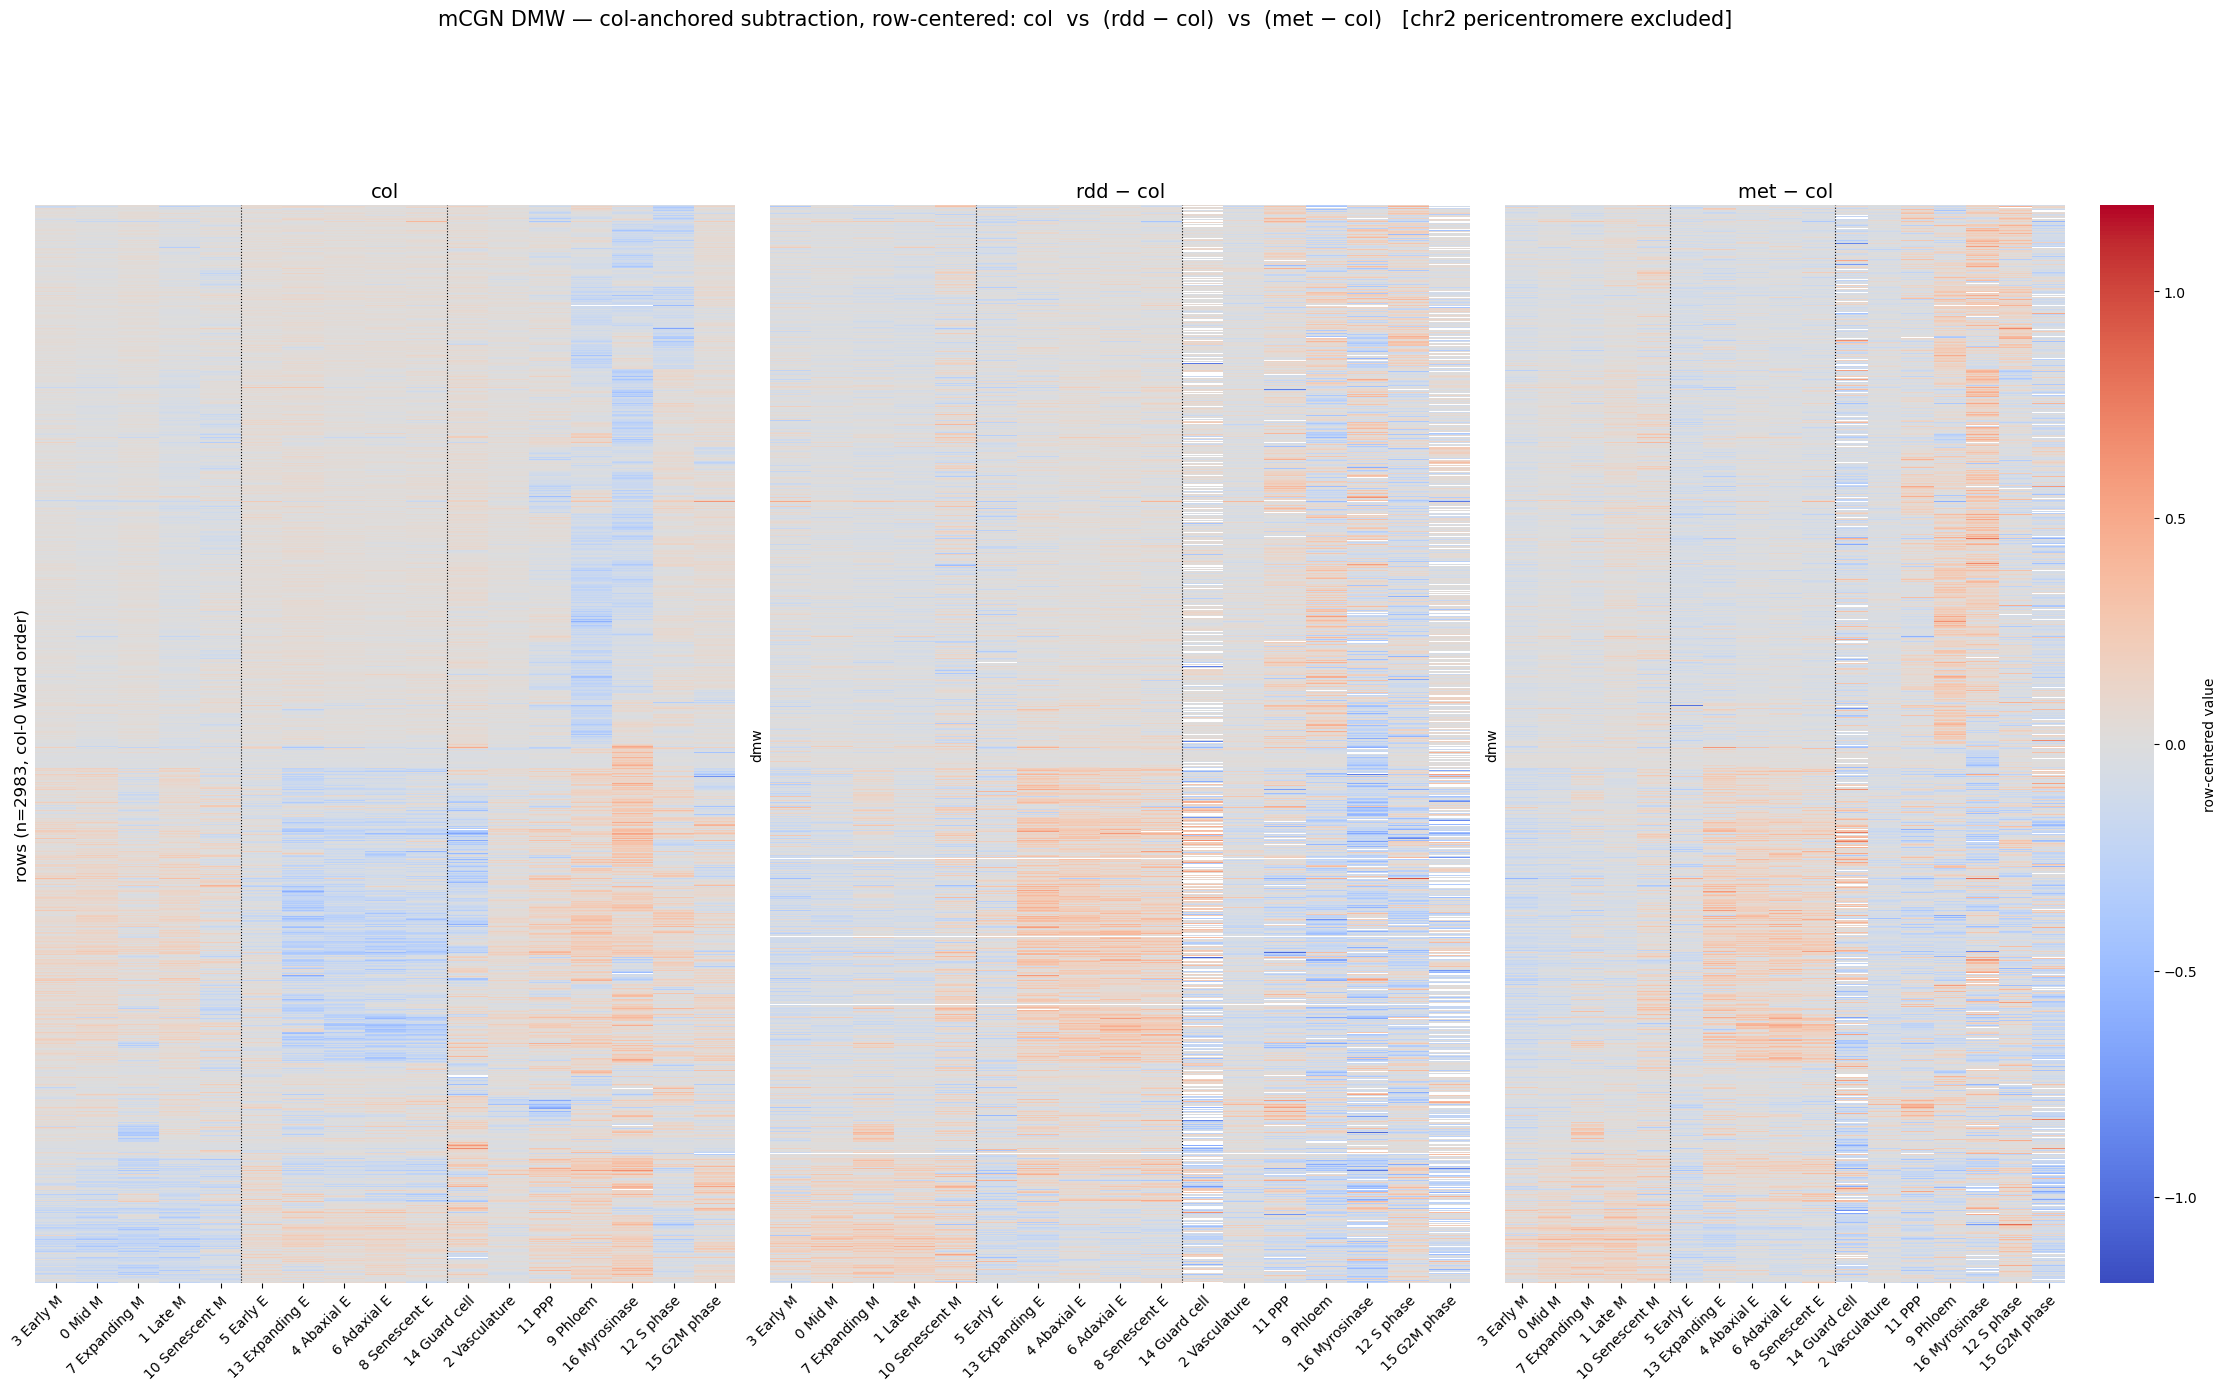


Per-DMW Pearson ρ between col residual and each (mutant − col) panel:
   rdd − col:  n=1811   median ρ = -0.585   frac ρ<0 = 88.8%   frac ρ<−0.5 = 59.7%
   met − col:  n=2524   median ρ = -0.827   frac ρ<0 = 98.3%   frac ρ<−0.5 = 85.3%


In [13]:
# Build differential panels from the col-anchored matrices, then ROW-CENTER
# each panel (subtract per-DMW mean across the 17 clusters) to remove the bulk
# hypermethylation/hypomethylation shift that otherwise washes the rdd and met
# panels uniformly red/blue.
anchored_diff = {
    "col":       anchored_lab["col"],
    "rdd − col": anchored_lab["rdd"] - anchored_lab["col"],
    "met − col": anchored_lab["met"] - anchored_lab["col"],
}

# Row-center: subtract per-DMW mean across clusters
anchored_diff_centered = {
    name: df.sub(df.mean(axis=1), axis=0)
    for name, df in anchored_diff.items()
}

# Report what the bulk shift was vs what remains after centering
print("Per-panel data range — before vs after row-centering:")
for name in anchored_diff:
    raw_arr = anchored_diff[name].to_numpy()
    cen_arr = anchored_diff_centered[name].to_numpy()
    print(f"  {name:>10s}:  raw [{np.nanmin(raw_arr):+.3f}, {np.nanmax(raw_arr):+.3f}]"
          f"   →  centered [{np.nanmin(cen_arr):+.3f}, {np.nanmax(cen_arr):+.3f}]")

# Symmetric coolwarm scale spanning all three CENTERED panels
vmax = max(np.nanmax(np.abs(df.to_numpy())) for df in anchored_diff_centered.values())
vmax = float(np.round(vmax, 2))
print(f"\nShared color scale (centered): ±{vmax:.2f}")

fig, axes = plt.subplots(
    1, 3, figsize=(28, 14), sharey=True,
    gridspec_kw={"wspace": 0.05},
)
for ax, (name, df) in zip(axes, anchored_diff_centered.items()):
    mat = df.reindex(row_order)
    sns.heatmap(
        mat, ax=ax,
        cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax,
        cbar=(name == list(anchored_diff_centered)[-1]),
        cbar_kws={"label": "row-centered value"},
        yticklabels=False,
    )
    ax.set_title(name, fontsize=14)
    ax.set_xlabel("")
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45, ha="right", rotation_mode="anchor",
    )
    for i, col_name in enumerate(mat.columns):
        if "Senescent M" in col_name or "Senescent E" in col_name:
            ax.axvline(i + 1, color="black", lw=0.8, linestyle=":")

axes[0].set_ylabel(f"rows (n={len(row_order)}, col-0 Ward order)", fontsize=12)
fig.suptitle(
    f"m{MC_TYPE} DMW — col-anchored subtraction, row-centered: "
    f"col  vs  (rdd − col)  vs  (met − col)   [chr2 pericentromere excluded]",
    fontsize=15, y=1.02,
)

out_path = f"{FIG_OUTDIR}/col_anchored_subtraction_rowcentered_chr2excl.svg"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"\nSaved heatmap: {out_path}")
plt.show()

# Per-DMW anticorrelation diagnostic.
# Note: Pearson ρ is invariant to per-row mean subtraction, so the ρ values
# below are unchanged by row-centering — but they confirm the anticorrelation
# the centered heatmap now makes visible.
print("\nPer-DMW Pearson ρ between col residual and each (mutant − col) panel:")
for name in ("rdd − col", "met − col"):
    common = anchored_diff_centered["col"].dropna().index.intersection(
        anchored_diff_centered[name].dropna().index
    )
    A = anchored_diff_centered["col"].loc[common].to_numpy()
    B = anchored_diff_centered[name].loc[common].to_numpy()
    num = (A * B).sum(axis=1)
    den = np.sqrt((A * A).sum(axis=1) * (B * B).sum(axis=1))
    rho = pd.Series(np.where(den > 0, num / den, np.nan), index=common).dropna()
    print(f"  {name:>10s}:  n={len(rho):4d}   median ρ = {rho.median():+.3f}   "
          f"frac ρ<0 = {(rho < 0).mean():.1%}   frac ρ<−0.5 = {(rho < -0.5).mean():.1%}")

In [14]:
import numpy as np, pandas as pd, statsmodels.api as sm

# Per-genotype residuals (re-fit within each genotype) so col is NOT inside rdd.
col = res_by_geno["col"].reindex(row_order)
rdd = res_by_geno["rdd"].reindex(row_order)

rows = []
for dmw in row_order:
    x, y = col.loc[dmw].to_numpy(float), rdd.loc[dmw].to_numpy(float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 4 or np.std(x[ok]) == 0:
        continue
    b = sm.OLS(y[ok], sm.add_constant(x[ok])).fit().params[1]
    rows.append((dmw, b, np.corrcoef(x[ok], y[ok])[0, 1]))

s = pd.DataFrame(rows, columns=["dmw", "slope_rdd_on_col", "pearson_r"])
print(f"median slope (rdd~col): {s.slope_rdd_on_col.median():+.3f}   "
      f"median r: {s.pearson_r.median():+.3f}")
print(f"frac slope<0  (true inverse):   {(s.slope_rdd_on_col<0).mean():.1%}")
print(f"frac 0<slope<1 (shrinkage/RTM): {((s.slope_rdd_on_col>0)&(s.slope_rdd_on_col<1)).mean():.1%}")

median slope (rdd~col): +0.154   median r: +0.142
frac slope<0  (true inverse):   35.6%
frac 0<slope<1 (shrinkage/RTM): 56.5%
